# 🛒 E-Commerce Sales Analysis — Student Project

**Dataset:** `ecommerce_sales.csv`  
**Topics Covered:** Pandas Series, DataFrames, Conditional Filtering, Useful Methods, GroupBy & MultiIndex, Combining DataFrames, Matplotlib Visualization

---

## 📋 Instructions
- Load the dataset using `pd.read_csv('ecommerce_sales.csv')`
- Answer each question by writing code in the cell below it
- Do **not** hardcode values — use pandas methods to compute them
- Run all cells top to bottom before submitting

---

## Dataset Description

| Column | Description |
|---|---|
| `order_id` | Unique order identifier |
| `customer_id` | Unique customer identifier |
| `product` | Product name |
| `category` | Product category (Electronics / Accessories) |
| `city` | City where order was placed |
| `region` | Region (North / South / West) |
| `month` | Month of order |
| `year` | Year of order (2023 or 2024) |
| `quantity` | Number of units ordered |
| `unit_price` | Price per unit (₹) |
| `discount_pct` | Discount percentage applied |
| `total_sales` | Total sale value (₹) |
| `payment_method` | Mode of payment |
| `rating` | Customer rating (1–5) |
| `returned` | Whether order was returned (Yes/No) |

In [2]:
# Run this cell first — import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Isha\Desktop\learning\python infi\ecommerce_sales.csv")
df.head()

,order_id,customer_id,product,category,city,region,month,year,quantity,unit_price,discount_pct,total_sales,payment_method,rating,returned
0,ORD0001,CUST052,Speaker,Accessories,Mumbai,West,Apr,2024,3,6906,5,20718,Net Banking,5,No
1,ORD0002,CUST015,Tablet,Electronics,Ahmedabad,West,Jul,2023,4,17760,0,71040,Debit Card,1,No
2,ORD0003,CUST072,Headphones,Accessories,Chennai,South,Mar,2024,2,5445,0,10890,UPI,2,No
3,ORD0004,CUST061,Laptop,Electronics,Chennai,South,Feb,2024,5,52899,10,264495,Debit Card,4,No
4,ORD0005,CUST021,Headphones,Accessories,Delhi,North,Nov,2024,2,6455,0,12910,Credit Card,5,No


---
## Q1 — Series & Basic Inspection
Create a **Pandas Series** from the `total_sales` column and display:
- Its **data type**
- The **index** of the Series
- The **first 5 values**

In [3]:
print(type(df["total_sales"]))

<class 'pandas.core.series.Series'>


In [52]:
df.index

RangeIndex(start=0, stop=300, step=1)

In [32]:
df["total_sales"].head()

0     20718
1     71040
2     10890
3    264495
4     12910
Name: total_sales, dtype: int64

---
## Q2 — DataFrame Basics
Display the **shape**, **column names**, and a **summary** (`info()`) of the DataFrame.
Also display **descriptive statistics** for all numeric columns using `describe()`.

In [5]:
df.shape

(300, 15)

In [6]:
df.columns

Index(['order_id', 'customer_id', 'product', 'category', 'city', 'region',
       'month', 'year', 'quantity', 'unit_price', 'discount_pct',
       'total_sales', 'payment_method', 'rating', 'returned'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        300 non-null    object
 1   customer_id     300 non-null    object
 2   product         300 non-null    object
 3   category        300 non-null    object
 4   city            300 non-null    object
 5   region          300 non-null    object
 6   month           300 non-null    object
 7   year            300 non-null    int64 
 8   quantity        300 non-null    int64 
 9   unit_price      300 non-null    int64 
 10  discount_pct    300 non-null    int64 
 11  total_sales     300 non-null    int64 
 12  payment_method  300 non-null    object
 13  rating          300 non-null    int64 
 14  returned        300 non-null    object
dtypes: int64(6), object(9)
memory usage: 35.3+ KB


In [8]:
df.describe()

,year,quantity,unit_price,discount_pct,total_sales,rating
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2023.606667,2.880000,22303.983333,7.666667,63899.200000,3.726667
std,0.489306,1.430298,16479.116396,6.585346,61411.434891,1.153135
min,2023.000000,1.000000,2066.000000,0.000000,3169.000000,1.000000
25%,2023.000000,2.000000,8664.000000,0.000000,21999.750000,3.000000
50%,2024.000000,3.000000,19417.000000,10.000000,42856.500000,4.000000
75%,2024.000000,4.000000,32356.250000,10.000000,95122.500000,5.000000
max,2024.000000,5.000000,57961.000000,20.000000,289805.000000,5.000000


---
## Q3 — Conditional Filtering (Single Condition)
Filter all orders where `total_sales` is **greater than ₹80,000**. How many such orders exist?

In [9]:
df[df["total_sales"] > 80000 ]

,order_id,customer_id,product,category,city,region,month,year,quantity,unit_price,discount_pct,total_sales,payment_method,rating,returned
3,ORD0004,CUST061,Laptop,Electronics,Chennai,South,Feb,2024,5,52899,10,264495,Debit Card,4,No
9,ORD0010,CUST022,Laptop,Electronics,Delhi,North,Mar,2024,4,53887,0,215548,Net Banking,5,No
10,ORD0011,CUST053,Tablet,Electronics,Chennai,South,Dec,2024,4,20266,20,81064,Debit Card,4,No
11,ORD0012,CUST002,Phone,Electronics,Bengaluru,South,Dec,2024,4,22666,5,90664,Credit Card,5,No
12,ORD0013,CUST030,Laptop,Electronics,Ahmedabad,West,Feb,2023,4,56188,15,224752,Debit Card,5,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,ORD0281,CUST030,Laptop,Electronics,Mumbai,West,Dec,2023,2,54371,0,108742,Net Banking,2,No
283,ORD0284,CUST069,Camera,Electronics,Hyderabad,South,May,2024,3,36225,15,108675,Debit Card,3,No
286,ORD0287,CUST019,Tablet,Electronics,Delhi,North,Apr,2023,5,18955,0,94775,Credit Card,1,No
291,ORD0292,CUST017,Tablet,Electronics,Delhi,North,Mar,2023,5,21106,10,105530,Net Banking,4,No


In [10]:
df[df["total_sales"] > 80000 ].count()

order_id          87
customer_id       87
product           87
category          87
city              87
region            87
month             87
year              87
quantity          87
unit_price        87
discount_pct      87
total_sales       87
payment_method    87
rating            87
returned          87
dtype: int64

---
## Q4 — Conditional Filtering (Multiple Conditions)
Filter orders that meet **all** of the following conditions:
- `category` is `'Electronics'`
- `rating` is **4 or 5**
- `returned` is `'No'`

Display the first 10 rows of the result.

In [11]:
df[(df["category"] == "Electronics" ) & ((df["rating"] == 4) | (df["rating"] == 5)) & (df["returned"] == "No")].head(10)

,order_id,customer_id,product,category,city,region,month,year,quantity,unit_price,discount_pct,total_sales,payment_method,rating,returned
3,ORD0004,CUST061,Laptop,Electronics,Chennai,South,Feb,2024,5,52899,10,264495,Debit Card,4,No
9,ORD0010,CUST022,Laptop,Electronics,Delhi,North,Mar,2024,4,53887,0,215548,Net Banking,5,No
10,ORD0011,CUST053,Tablet,Electronics,Chennai,South,Dec,2024,4,20266,20,81064,Debit Card,4,No
11,ORD0012,CUST002,Phone,Electronics,Bengaluru,South,Dec,2024,4,22666,5,90664,Credit Card,5,No
12,ORD0013,CUST030,Laptop,Electronics,Ahmedabad,West,Feb,2023,4,56188,15,224752,Debit Card,5,No
16,ORD0017,CUST060,Phone,Electronics,Delhi,North,Aug,2024,1,25122,20,25122,Net Banking,5,No
17,ORD0018,CUST021,Tablet,Electronics,Ahmedabad,West,Oct,2024,4,22124,10,88496,UPI,4,No
19,ORD0020,CUST076,Phone,Electronics,Mumbai,West,Jul,2023,1,26699,15,26699,Cash,5,No
21,ORD0022,CUST022,Camera,Electronics,Delhi,North,Jul,2024,5,35900,0,179500,Debit Card,5,No
25,ORD0026,CUST060,Tablet,Electronics,Pune,West,Jun,2024,5,20117,20,100585,Debit Card,5,No


---
## Q5 — isin() Filtering
Filter all orders placed in **South or West regions** using `.isin()`. What is the **total revenue** from these regions?

In [12]:
options = ["South" , "West" ]
df = df["region"].isin(options)
print(df)

0       True
1       True
2       True
3       True
4      False
       ...  
295     True
296     True
297     True
298     True
299     True
Name: region, Length: 300, dtype: bool


In [56]:
total_revenue = df[df["region"].isin(["South" , "West"])]["total_sales"].sum()
print(total_revenue)

16166188


---
## Q6 — apply() with a Custom Function
Create a new column called `price_tier` using `.apply()` with the following rules:
- `unit_price` < 10,000 → `'Budget'`
- 10,000 ≤ `unit_price` < 30,000 → `'Mid-Range'`
- `unit_price` ≥ 30,000 → `'Premium'`

Display the **value counts** of the new column.

In [22]:
def yelp(price):
    if price < 10000 :
        return "Budget"
    elif price > 10000 and price < 30000:
        return "Mid Range"
    else:
        return "Premium" 


In [35]:
df["price_tier"] = df["unit_price"].apply(yelp)
df

,order_id,customer_id,product,category,city,region,month,year,quantity,unit_price,discount_pct,total_sales,payment_method,rating,returned,price_tier
0,ORD0001,CUST052,Speaker,Accessories,Mumbai,West,Apr,2024,3,6906,5,20718,Net Banking,5,No,Budget
1,ORD0002,CUST015,Tablet,Electronics,Ahmedabad,West,Jul,2023,4,17760,0,71040,Debit Card,1,No,Mid Range
2,ORD0003,CUST072,Headphones,Accessories,Chennai,South,Mar,2024,2,5445,0,10890,UPI,2,No,Budget
3,ORD0004,CUST061,Laptop,Electronics,Chennai,South,Feb,2024,5,52899,10,264495,Debit Card,4,No,Premium
4,ORD0005,CUST021,Headphones,Accessories,Delhi,North,Nov,2024,2,6455,0,12910,Credit Card,5,No,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,ORD0296,CUST006,Tablet,Electronics,Chennai,South,Dec,2024,3,19597,0,58791,UPI,4,No,Mid Range
296,ORD0297,CUST037,Smartwatch,Accessories,Pune,West,Jun,2023,2,12205,20,24410,Cash,3,No,Mid Range
297,ORD0298,CUST024,Headphones,Accessories,Bengaluru,South,Feb,2024,3,6807,10,20421,Credit Card,3,No,Budget
298,ORD0299,CUST046,Smartwatch,Accessories,Bengaluru,South,Mar,2024,5,9814,10,49070,Debit Card,5,Yes,Budget


---
## Q7 — sort_values() and nlargest()
1. Sort the DataFrame by `total_sales` in **descending order** and display the top 5 rows.
2. Using `nlargest()`, find the **top 3 orders** by `total_sales`.

In [34]:
df.sort_values("total_sales" , ascending = False)

,order_id,customer_id,product,category,city,region,month,year,quantity,unit_price,discount_pct,total_sales,payment_method,rating,returned
293,ORD0294,CUST030,Laptop,Electronics,Chennai,South,Jan,2023,5,57961,20,289805,Net Banking,4,No
218,ORD0219,CUST011,Laptop,Electronics,Chennai,South,Mar,2024,5,57868,0,289340,UPI,1,No
250,ORD0251,CUST066,Laptop,Electronics,Chennai,South,Nov,2023,5,57567,10,287835,Credit Card,2,No
227,ORD0228,CUST002,Laptop,Electronics,Ahmedabad,West,May,2024,5,55762,15,278810,Net Banking,2,Yes
244,ORD0245,CUST075,Laptop,Electronics,Mumbai,West,Aug,2024,5,55110,0,275550,Credit Card,3,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,ORD0249,CUST025,Headphones,Accessories,Ahmedabad,West,Dec,2024,1,4626,5,4626,Cash,1,No
200,ORD0201,CUST073,Headphones,Accessories,Chennai,South,Oct,2023,1,4560,0,4560,Cash,2,No
140,ORD0141,CUST045,Headphones,Accessories,Mumbai,West,Feb,2023,1,4551,15,4551,Net Banking,2,No
162,ORD0163,CUST051,Headphones,Accessories,Mumbai,West,May,2024,1,3917,0,3917,Cash,1,No


In [33]:
df["total_sales"].nlargest(3)

293    289805
218    289340
250    287835
Name: total_sales, dtype: int64

---
## Q8 — value_counts(), unique(), and nunique()
1. How many **unique products** are in the dataset?
2. List all **unique cities**.
3. What is the **distribution of payment methods** (use `value_counts()`)?

In [38]:
df["city"].unique()


array(['Mumbai', 'Ahmedabad', 'Chennai', 'Delhi', 'Pune', 'Bengaluru',
       'Hyderabad'], dtype=object)

In [39]:
df["product"].unique()

array(['Speaker', 'Tablet', 'Headphones', 'Laptop', 'Smartwatch', 'Phone',
       'Camera'], dtype=object)

In [40]:
df["payment_method"].value_counts()

payment_method
Net Banking    67
Debit Card     63
Cash           61
Credit Card    57
UPI            52
Name: count, dtype: int64

---
## Q9 — Correlation Analysis
Compute the **correlation matrix** for all numeric columns.
Which two numeric columns have the **highest positive correlation**? (Use `.corr()`)

In [45]:
df.select_dtypes(exclude = "object").corr()

,year,quantity,unit_price,discount_pct,total_sales,rating
year,1.000000,0.042245,0.030765,-0.073001,0.033754,0.022208
quantity,0.042245,1.000000,-0.014315,0.002130,0.529267,0.008436
unit_price,0.030765,-0.014315,1.000000,-0.025162,0.748234,-0.016721
discount_pct,-0.073001,0.002130,-0.025162,1.000000,-0.011234,0.091902
total_sales,0.033754,0.529267,0.748234,-0.011234,1.000000,-0.067475
rating,0.022208,0.008436,-0.016721,0.091902,-0.067475,1.000000


---
## Q10 — GroupBy: Revenue by Region
Using `groupby()`, calculate the **total sales, average unit price, and order count** for each `region`.
Sort the result by total sales in descending order.

In [8]:
df.groupby("region")["total_sales"].sum().sort_values(ascending = False)

region
South    8099025
West     8067163
North    3003572
Name: total_sales, dtype: int64

In [5]:
df.groupby("region")["unit_price"].mean()

region
North    21184.478261
South    21231.186047
West     23823.088000
Name: unit_price, dtype: float64

In [7]:
df.groupby("region").size()

region
North     46
South    129
West     125
dtype: int64

---
## Q11 — GroupBy: Best Selling Product per Region
Using `groupby()` on **both `region` and `product`**, find the **total quantity sold** for each combination.
Then identify which product sold the **most units in each region**.

In [12]:
df.groupby(["region" , "product"])["quantity"].sum()

region  product   
North   Camera        26
        Headphones    11
        Laptop        14
        Phone         20
        Smartwatch    12
        Speaker       35
        Tablet        18
South   Camera        37
        Headphones    72
        Laptop        53
        Phone         48
        Smartwatch    65
        Speaker       58
        Tablet        52
West    Camera        34
        Headphones    46
        Laptop        56
        Phone         70
        Smartwatch    63
        Speaker       32
        Tablet        42
Name: quantity, dtype: int64

---
## Q12 — Combining DataFrames
You are given two separate DataFrames extracted from the main data:
- `df_2023`: all orders from year 2023
- `df_2024`: all orders from year 2024

1. **Concatenate** them back together along rows (axis=0) and confirm the total row count.
2. Create a small **product info table** (product → category) and **merge** it with a summary of total sales per product.

*(Tip: Use `pd.concat()` and `pd.merge()`)*

In [76]:
# Q12 — Your code here
df_2023 = df[df['year'] == 2023].reset_index(drop=True)
df_2024 = df[df['year'] == 2024].reset_index(drop=True)


display(df_2023)
display(df_2024)

,order_id,customer_id,product,category,city,region,month,year,quantity,unit_price,discount_pct,total_sales,payment_method,rating,returned
0,ORD0002,CUST015,Tablet,Electronics,Ahmedabad,West,Jul,2023,4,17760,0,71040,Debit Card,1,No
1,ORD0006,CUST075,Speaker,Accessories,Delhi,North,Oct,2023,1,7947,10,7947,Debit Card,4,No
2,ORD0013,CUST030,Laptop,Electronics,Ahmedabad,West,Feb,2023,4,56188,15,224752,Debit Card,5,No
3,ORD0014,CUST038,Phone,Electronics,Chennai,South,Mar,2023,5,22671,10,113355,Net Banking,3,No
4,ORD0019,CUST033,Camera,Electronics,Hyderabad,South,Jul,2023,2,37585,15,75170,Credit Card,4,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,ORD0292,CUST017,Tablet,Electronics,Delhi,North,Mar,2023,5,21106,10,105530,Net Banking,4,No
114,ORD0293,CUST044,Headphones,Accessories,Pune,West,Nov,2023,2,5325,0,10650,Cash,5,No
115,ORD0294,CUST030,Laptop,Electronics,Chennai,South,Jan,2023,5,57961,20,289805,Net Banking,4,No
116,ORD0297,CUST037,Smartwatch,Accessories,Pune,West,Jun,2023,2,12205,20,24410,Cash,3,No


,order_id,customer_id,product,category,city,region,month,year,quantity,unit_price,discount_pct,total_sales,payment_method,rating,returned
0,ORD0001,CUST052,Speaker,Accessories,Mumbai,West,Apr,2024,3,6906,5,20718,Net Banking,5,No
1,ORD0003,CUST072,Headphones,Accessories,Chennai,South,Mar,2024,2,5445,0,10890,UPI,2,No
2,ORD0004,CUST061,Laptop,Electronics,Chennai,South,Feb,2024,5,52899,10,264495,Debit Card,4,No
3,ORD0005,CUST021,Headphones,Accessories,Delhi,North,Nov,2024,2,6455,0,12910,Credit Card,5,No
4,ORD0007,CUST075,Smartwatch,Accessories,Ahmedabad,West,Jul,2024,1,10719,10,10719,Credit Card,4,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,ORD0291,CUST049,Smartwatch,Accessories,Chennai,South,May,2024,2,14779,10,29558,Net Banking,5,No
178,ORD0295,CUST046,Headphones,Accessories,Delhi,North,Oct,2024,1,4919,15,4919,Net Banking,4,No
179,ORD0296,CUST006,Tablet,Electronics,Chennai,South,Dec,2024,3,19597,0,58791,UPI,4,No
180,ORD0298,CUST024,Headphones,Accessories,Bengaluru,South,Feb,2024,3,6807,10,20421,Credit Card,3,No


---
## Q13 — Matplotlib: Bar Chart
Plot a **vertical bar chart** showing **total sales by product**.
- Add a title, axis labels, and rotate x-axis ticks 45°.
- Use a meaningful color.

In [60]:
df["product"].unique()

array(['Speaker', 'Tablet', 'Headphones', 'Laptop', 'Smartwatch', 'Phone',
       'Camera'], dtype=object)

In [69]:
product_rev = df.groupby("product")["total_sales"].sum()
display(product_rev)

product
Camera        3374905
Headphones     670389
Laptop        6767243
Phone         3403549
Smartwatch    1680161
Speaker       1003812
Tablet        2269701
Name: total_sales, dtype: int64

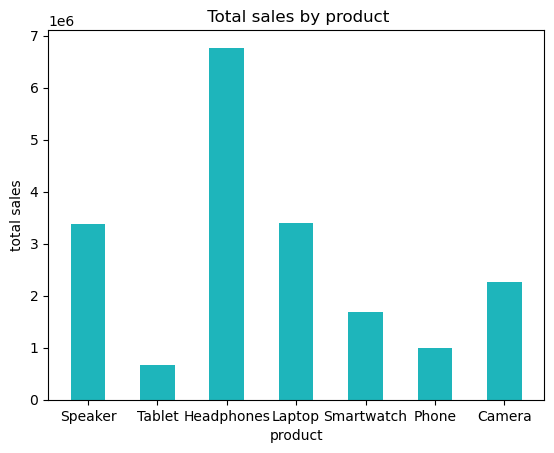

In [74]:
product = ['Speaker', 'Tablet', 'Headphones', 'Laptop', 'Smartwatch', 'Phone',
           'Camera']
colours = [ "#1EB5BB" ]
plt.bar(product, product_rev , width = 0.5, color = colours )
plt.title(" Total sales by product")
plt.xlabel("product")
plt.ylabel("total sales")
plt.show()


---
## Q14 — Matplotlib: Line Plot
The dataset has a `month` column. Create a **line plot** showing the **number of orders per month** for **2024 only**.
Order the months correctly (Jan → Dec) on the x-axis.

In [93]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

month_revenue = df_2024.groupby("month").size().reindex(month_order)
display(month_revenue)

month
Jan    16
Feb    19
Mar    14
Apr    12
May    11
Jun    11
Jul    10
Aug    19
Sep    14
Oct    17
Nov    21
Dec    18
dtype: int64

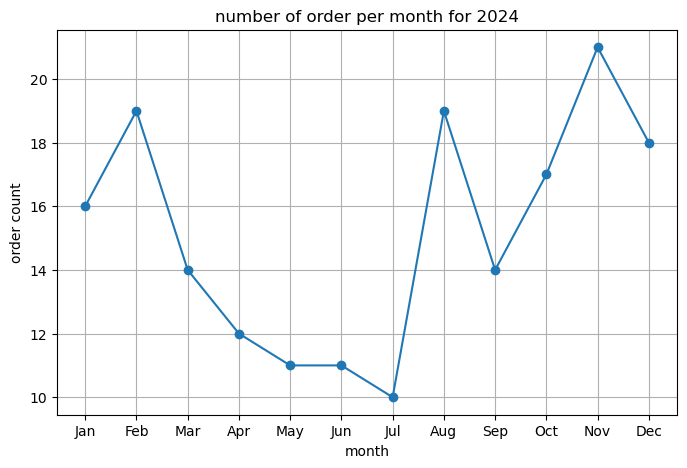

In [94]:
plt.figure(figsize= (8,5))
plt.plot(month_revenue.index , month_revenue.values , marker = "o" )
plt.xlabel("month")
plt.ylabel("order count")
plt.title("number of order per month for 2024")
plt.grid(True)
plt.show()

---
## Q15 — Matplotlib: Scatter Plot
Create a **scatter plot** with:
- X-axis: `unit_price`
- Y-axis: `rating`
- Color points by `category` (use different colors for Electronics vs Accessories)

Does a higher price lead to a better rating? Comment in a markdown cell below your plot.

In [14]:
electronics = df[df["category"] == "Electronics"]
accessories = df[df["category"] == "Accessories"]

Text(0.5, 1.0, 'Electronics vs Accessories')

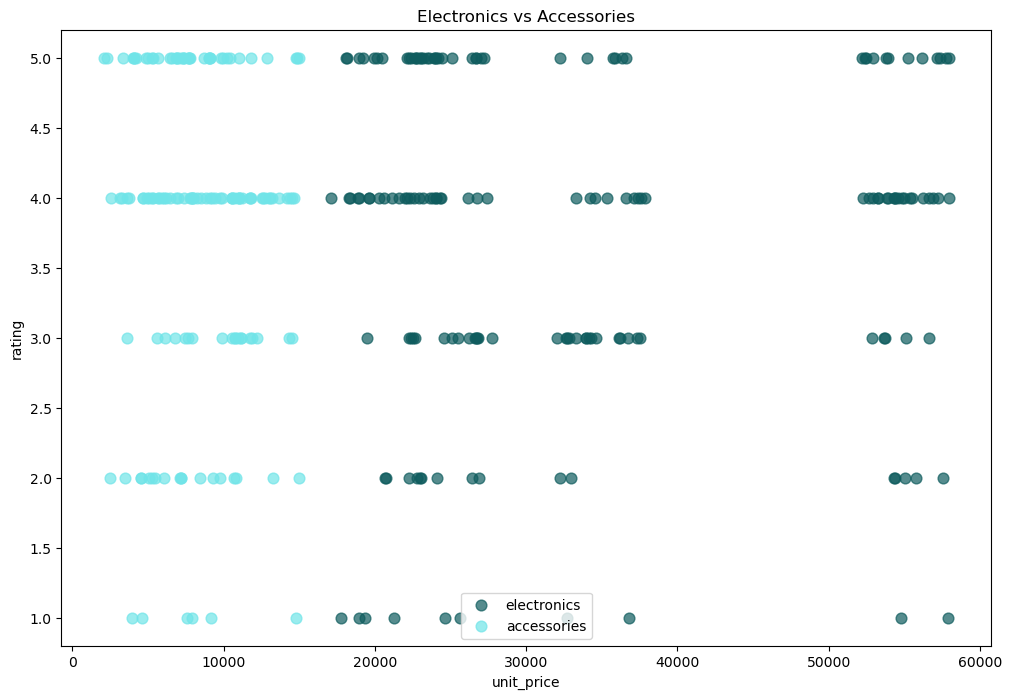

In [18]:
plt.figure(figsize=(12,8))
plt.scatter(electronics["unit_price"] , electronics["rating"], label = "electronics" , color = "#0F5C5E" , alpha = 0.7 , s = 60 )
plt.scatter(accessories["unit_price"] , accessories["rating"], label = "accessories", color = "#70E4E8" , alpha = 0.7 , s = 60 )
plt.xlabel("unit_price")
plt.ylabel("rating")
plt.legend()
plt.title("Electronics vs Accessories")

**Your Observation:** = there is no strong relationship between the two.

---
## Multi-Chart Dashboard
Create a **2×2 subplot figure** containing:
1. Bar chart — Total sales by region
2. Pie chart — Share of payment methods
3. Histogram — Distribution of `rating`
4. Bar chart — Average rating per product

Use `plt.subplots(2, 2, figsize=(14, 10))` and add titles to each subplot. Resarch about this command and try to implemnt it creates multiple charts at once

In [19]:
total_region = df.groupby("region")["total_sales"].sum()
display(total_region)

region
North    3003572
South    8099025
West     8067163
Name: total_sales, dtype: int64

AttributeError: 'Series' object has no attribute 'value'

<Figure size 1200x800 with 0 Axes>

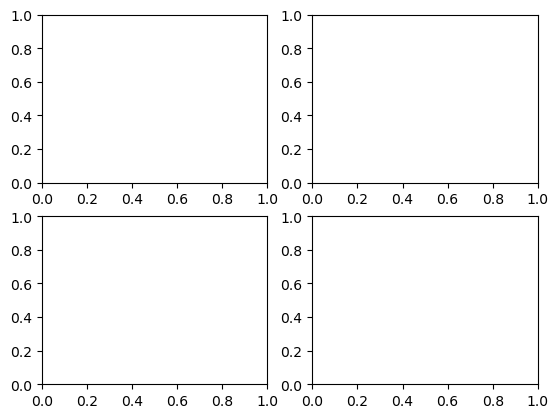

In [24]:
## Bar Chart
plt.figure(figsize = (12,8))
plt.subplots(2,2)
plt.bar(total_region.index , total_region.value , width = 0.5 , color = "#6A5ACD")
plt.xlabel("region")
plt.ylabel("total sales")
plt.title("Total sales by Region")
plt.show()



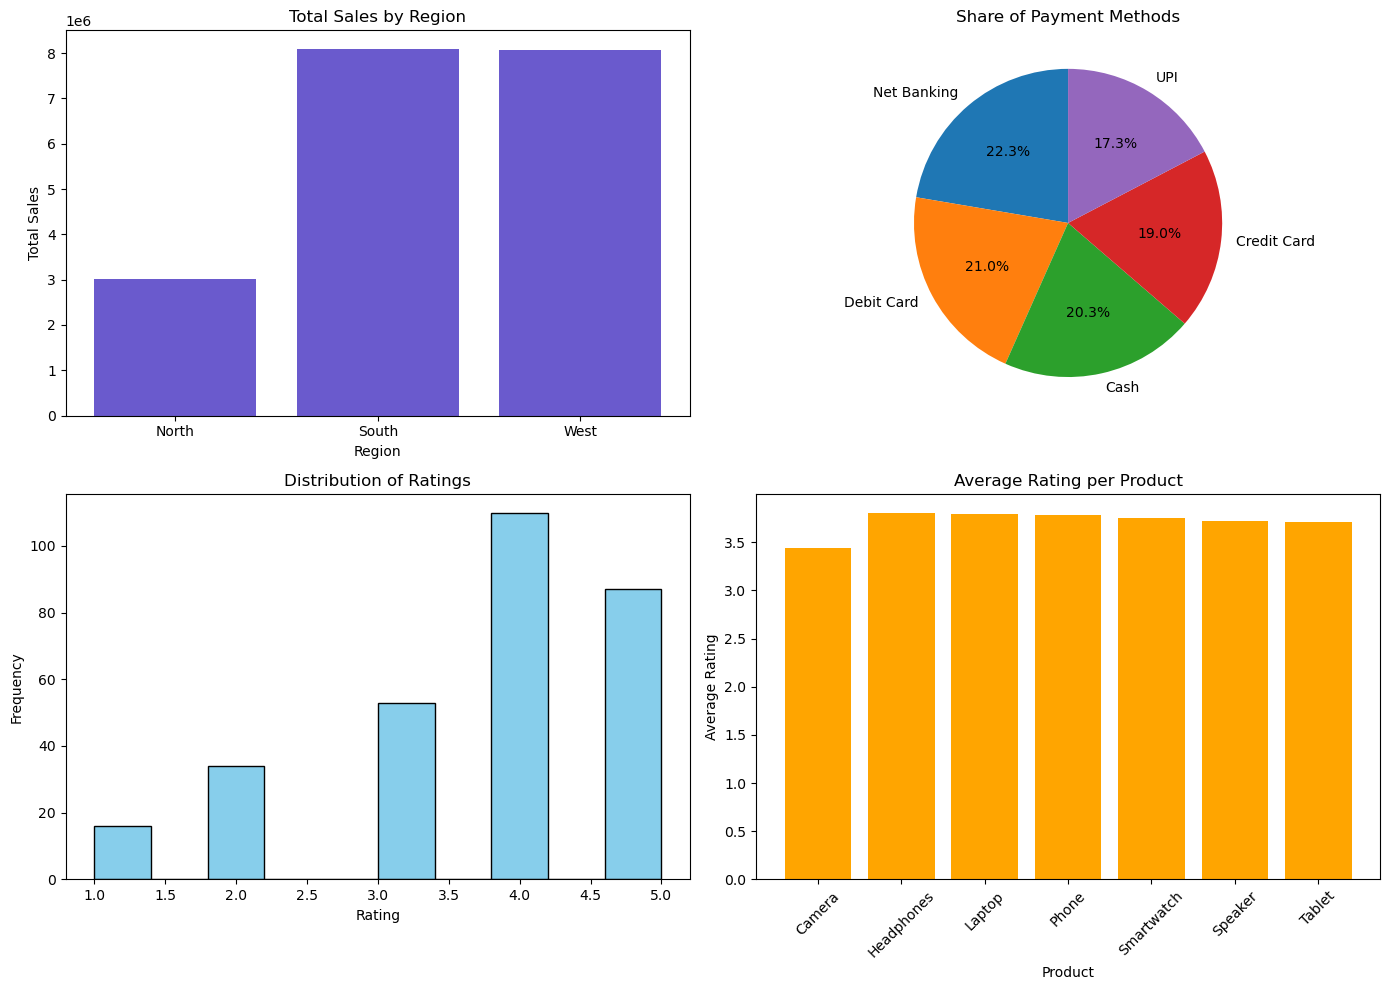

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(14,10))

# 1. Bar Chart - Total Sales by Region
ax[0,0].bar(total_region.index,
            total_region.values,
            color="#6A5ACD")

ax[0,0].set_title("Total Sales by Region")
ax[0,0].set_xlabel("Region")
ax[0,0].set_ylabel("Total Sales")


# 2. Pie Chart - Payment Methods
payment = df["payment_method"].value_counts()

ax[0,1].pie(payment.values,
            labels=payment.index,
            autopct="%1.1f%%",
            startangle=90)

ax[0,1].set_title("Share of Payment Methods")


# 3. Histogram - Ratings
ax[1,0].hist(df["rating"],
             bins=10,
             color="skyblue",
             edgecolor="black")

ax[1,0].set_title("Distribution of Ratings")
ax[1,0].set_xlabel("Rating")
ax[1,0].set_ylabel("Frequency")


# 4. Bar Chart - Average Rating per Product
avg_rating = df.groupby("product")["rating"].mean()

ax[1,1].bar(avg_rating.index,
            avg_rating.values,
            color="orange")

ax[1,1].set_title("Average Rating per Product")
ax[1,1].set_xlabel("Product")
ax[1,1].set_ylabel("Average Rating")
ax[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()